In [21]:
import pandas as pd
from catboost import CatBoostRegressor


In [23]:
train = pd.read_csv("../data/train.csv")
test = pd.read_csv("../data/test_x.csv")


In [2]:
train.columns

Index(['id', 'yas', 'cinsiyet', 'meslek', 'vucut_kitle_indeksi', 'ulke',
       'rem_yuzdesi', 'derin_uyku_yuzdesi', 'uykuya_dalma_suresi_dk',
       'gecelik_uyanma_sayisi', 'uyku_oncesi_kafein_mg',
       'uyku_oncesi_ekran_suresi_dk', 'gunluk_adim_sayisi',
       'sekerleme_suresi_dk', 'stres_skoru', 'gunluk_calisma_saati',
       'kronotip', 'ruh_sagligi_durumu', 'dinlenik_nabiz_bpm',
       'oda_sicakligi_celsius', 'hafta_sonu_uyku_farki_saat', 'mevsim',
       'gun_tipi', 'bilissel_performans_skoru'],
      dtype='object')

In [3]:
test.columns

Index(['id', 'yas', 'cinsiyet', 'meslek', 'vucut_kitle_indeksi', 'ulke',
       'rem_yuzdesi', 'derin_uyku_yuzdesi', 'uykuya_dalma_suresi_dk',
       'gecelik_uyanma_sayisi', 'uyku_oncesi_kafein_mg',
       'uyku_oncesi_ekran_suresi_dk', 'gunluk_adim_sayisi',
       'sekerleme_suresi_dk', 'stres_skoru', 'gunluk_calisma_saati',
       'kronotip', 'ruh_sagligi_durumu', 'dinlenik_nabiz_bpm',
       'oda_sicakligi_celsius', 'hafta_sonu_uyku_farki_saat', 'mevsim',
       'gun_tipi'],
      dtype='object')

In [24]:
target = "bilissel_performans_skoru"

X = train.drop(target, axis=1)
y = train[target]

In [5]:
cat_features = X.select_dtypes(include=["object"]).columns.tolist()

cat_features

['cinsiyet',
 'meslek',
 'ulke',
 'kronotip',
 'ruh_sagligi_durumu',
 'mevsim',
 'gun_tipi']

In [6]:
for col in cat_features:
    X[col] = X[col].fillna("missing")
    test[col] = test[col].fillna("missing")

In [7]:
from catboost import CatBoostRegressor

model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    loss_function="RMSE",
    verbose=100
)

model.fit(
    X,
    y,
    cat_features=cat_features
)

0:	learn: 2.1750137	total: 65.8ms	remaining: 1m 5s
100:	learn: 1.2434455	total: 859ms	remaining: 7.65s
200:	learn: 1.2126328	total: 1.66s	remaining: 6.59s
300:	learn: 1.1998693	total: 2.46s	remaining: 5.72s
400:	learn: 1.1915075	total: 3.32s	remaining: 4.96s
500:	learn: 1.1853247	total: 4.07s	remaining: 4.05s
600:	learn: 1.1793313	total: 4.81s	remaining: 3.19s
700:	learn: 1.1733296	total: 5.64s	remaining: 2.41s
800:	learn: 1.1680252	total: 6.43s	remaining: 1.6s
900:	learn: 1.1624513	total: 7.16s	remaining: 787ms
999:	learn: 1.1564181	total: 7.92s	remaining: 0us


CatBoostRegressor(depth=6, iterations=1000, learning_rate=0.05, loss_function='RMSE', verbose=100)

In [8]:
preds = model.predict(test)

preds[:5]

array([6.09731832, 6.88364837, 3.08255653, 7.16506847, 3.78172834])

In [25]:
preds = preds.clip(0, 10)

In [9]:
sample = pd.read_csv("../data/sample_submission.csv")

sample.head()

,id,bilissel_performans_skoru
0,1,7.85
1,2,4.32


In [10]:
submission = pd.DataFrame({
    "id": test["id"],
    "bilissel_performans_skoru": preds
})

submission.head()

,id,bilissel_performans_skoru
0,1,6.097318
1,2,6.883648
2,3,3.082557
3,4,7.165068
4,5,3.781728


In [11]:
submission.to_csv("../submissions/sub1.csv", index=False)

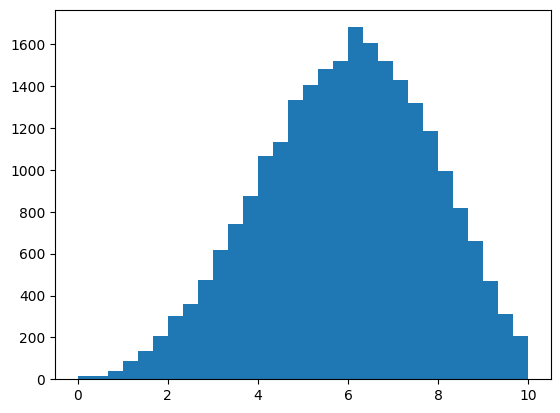

In [26]:
import matplotlib.pyplot as plt

plt.hist(preds, bins=30)
plt.show()